# 1. Setup

In [15]:
from google.colab import drive
drive.mount('/content/drive')

!pip install mir_eval -q

DRIVE_DATASETS = '/content/drive/MyDrive/ECE 490 Neural Networks/Final Project/Datasets'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Extract audio archives

In [16]:
import os

os.makedirs('/content/ballroom', exist_ok=True)
!tar -xzf "{DRIVE_DATASETS}/ballroom.tar.gz" -C /content/ballroom

os.makedirs('/content/gtzan', exist_ok=True)
!unzip -qo "{DRIVE_DATASETS}/GTZAN.zip" -d /content/gtzan

^C


## Clone annotation repos

In [17]:
if not os.path.exists('/content/ballroom_annotations'):
    !git clone -q https://github.com/CPJKU/BallroomAnnotations.git \
        /content/ballroom_annotations

if not os.path.exists('/content/gtzan_annotations'):
    !git clone -q https://github.com/TempoBeatDownbeat/gtzan_tempo_beat.git \
        /content/gtzan_annotations

## Loaders and path helpers

In [18]:
import numpy as np
from pathlib import Path

def load_beats(ann_path):
    """Load a .beats file. Two-column format: <time_seconds> <beat_position>.
    Works for both Ballroom and GTZAN.
    """
    times, positions = [], []
    with open(ann_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                times.append(float(parts[0]))
                positions.append(int(parts[1]))
    return np.array(times), np.array(positions)

def dataset_of(wav_path):
    return 'ballroom' if '/ballroom/' in wav_path else 'gtzan'

def annotation_path(wav_path):
    """Unified: returns the .beats path for any track from either dataset."""
    stem = Path(wav_path).stem
    if dataset_of(wav_path) == 'ballroom':
        return f'/content/ballroom_annotations/{stem}.beats'
    else:
        # 'blues.00000' → 'gtzan_blues_00000'
        ann_stem = 'gtzan_' + '_'.join(stem.split('.'))
        return f'/content/gtzan_annotations/beats/{ann_stem}.beats'

## Build combined track list

In [19]:
import glob

ballroom_wavs = sorted(glob.glob('/content/ballroom/**/*.wav', recursive=True))
gtzan_wavs = sorted(glob.glob('/content/gtzan/**/*.wav', recursive=True)) + \
             sorted(glob.glob('/content/gtzan/**/*.au',  recursive=True))

# Filter out tracks missing annotations (1 in GTZAN: reggae.00086):
gtzan_wavs = [w for w in gtzan_wavs if os.path.exists(annotation_path(w))]

all_wavs = ballroom_wavs + gtzan_wavs
print(f"Ballroom: {len(ballroom_wavs)}  GTZAN: {len(gtzan_wavs)}  Total: {len(all_wavs)}")

Ballroom: 560  GTZAN: 999  Total: 1559


## Processing pipeline and verification plots

In [20]:
import librosa
import matplotlib.pyplot as plt

# Audio / feature parameters — constants for the whole project.
SR      = 22050   # sample rate
HOP     = 220     # samples per frame → 100 fps
N_FFT   = 2048    # FFT window
N_MELS  = 81      # mel bins
FPS     = SR / HOP

def process_track(wav_path):
    """Audio file → (log_mel [N_MELS, T], target [T], beat_times)."""
    audio, _ = librosa.load(wav_path, sr=SR, mono=True)

    mel = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
    log_mel = librosa.power_to_db(mel, ref=np.max)

    beat_times, _ = load_beats(annotation_path(wav_path))
    n_frames = log_mel.shape[1]
    beat_frames = np.round(beat_times * FPS).astype(int)
    beat_frames = beat_frames[beat_frames < n_frames]

    # Gaussian-smoothed target: each beat becomes a small bump (σ=2 frames, ±20 ms).
    target = np.zeros(n_frames, dtype=np.float32)
    sigma, radius = 2.0, 6
    for bf in beat_frames:
        lo, hi = max(0, bf - radius), min(n_frames, bf + radius + 1)
        offsets = np.arange(lo, hi) - bf
        target[lo:hi] = np.maximum(
            target[lo:hi], np.exp(-0.5 * (offsets / sigma) ** 2))

    return log_mel, target, beat_times

def plot_track(wav_path, window_s=10):
    """Plot spectrogram + target with annotated beats overlaid, for QA."""
    log_mel, target, beat_times = process_track(wav_path)
    max_frame = int(window_s * FPS)
    t_axis = np.arange(max_frame) / FPS

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    axes[0].imshow(log_mel[:, :max_frame], aspect='auto', origin='lower',
                   extent=[0, window_s, 0, N_MELS], cmap='magma')
    axes[0].set_title(f'{dataset_of(wav_path)} — {Path(wav_path).name}')
    axes[0].set_ylabel('mel bin')

    axes[1].plot(t_axis, target[:max_frame], linewidth=1)
    axes[1].vlines(beat_times[beat_times < window_s], 0, 1,
                   colors='red', alpha=0.4, linestyles='dashed',
                   label='annotated beats')
    axes[1].set_xlabel('time (s)')
    axes[1].set_ylabel('beat target')
    axes[1].set_ylim(-0.05, 1.1)
    axes[1].legend(loc='upper right')
    plt.tight_layout()
    plt.show()

### Spot check

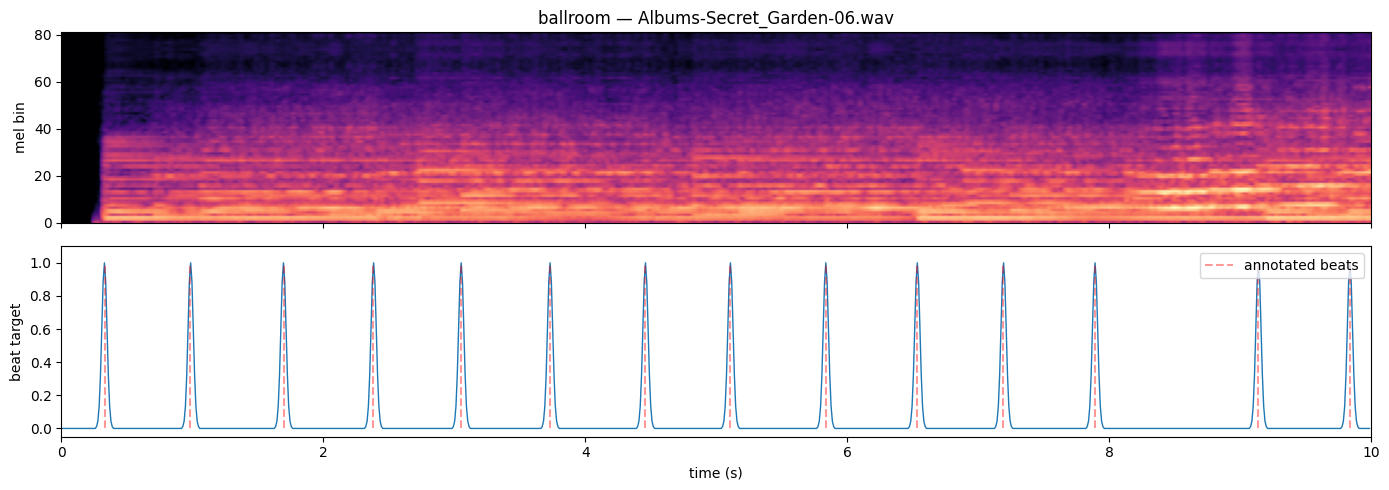

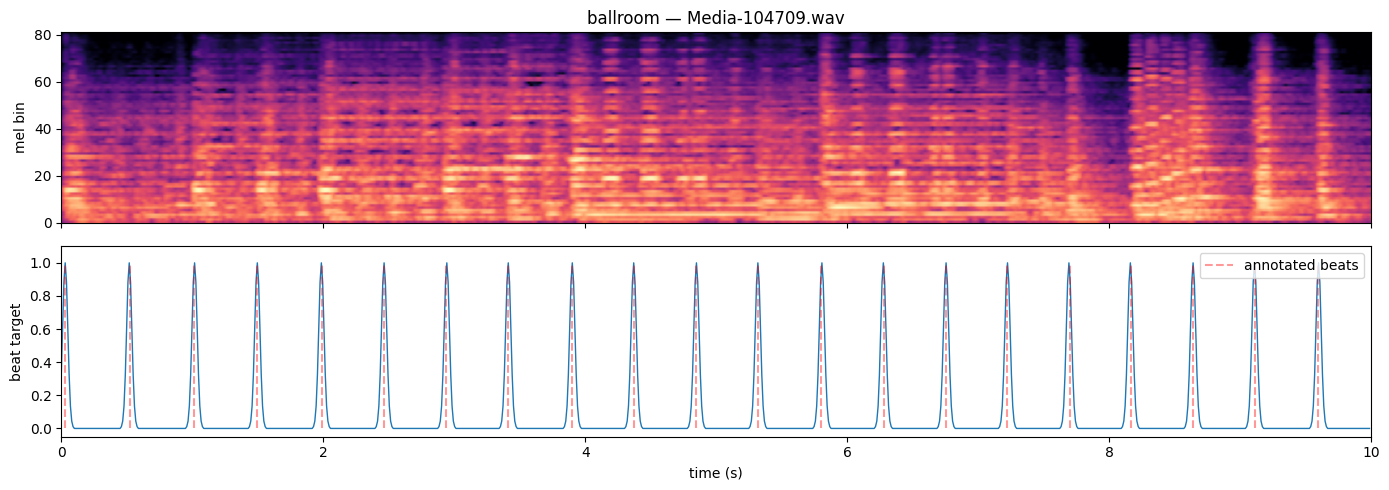

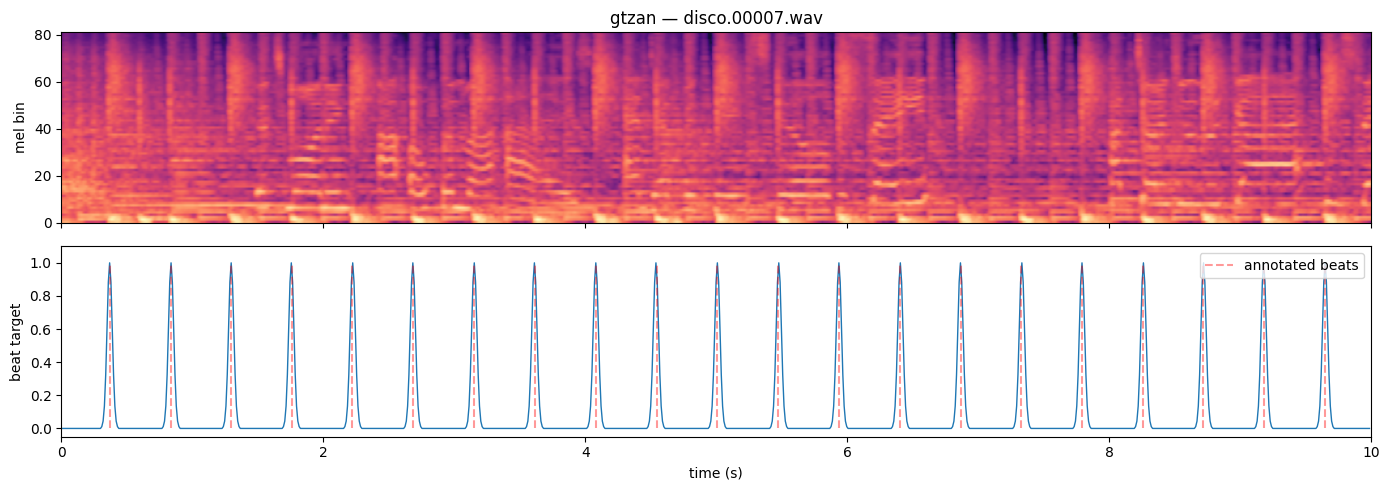

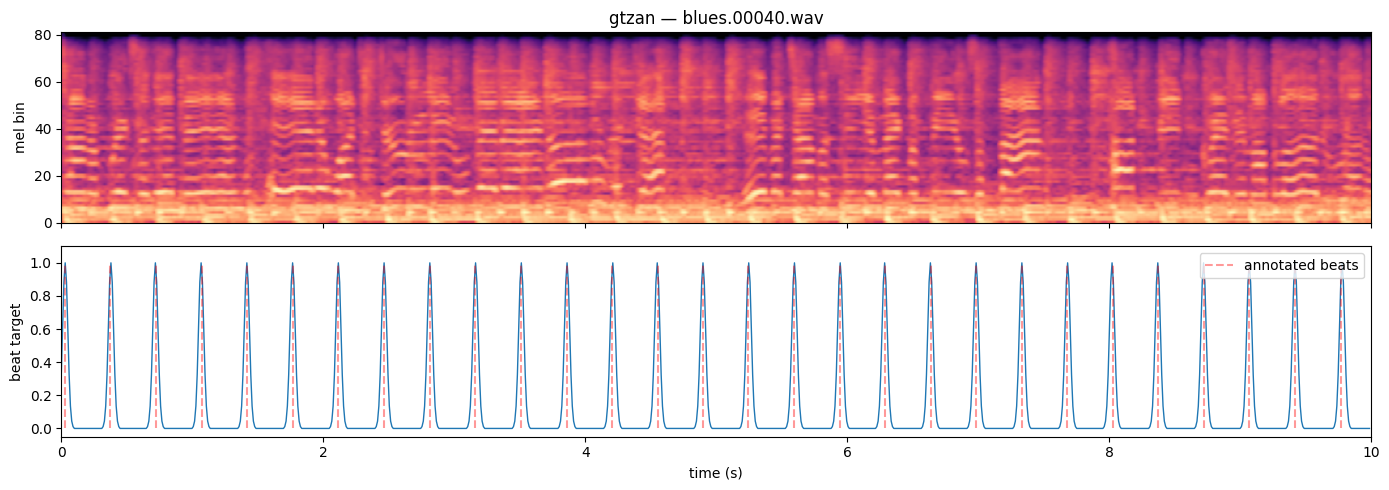

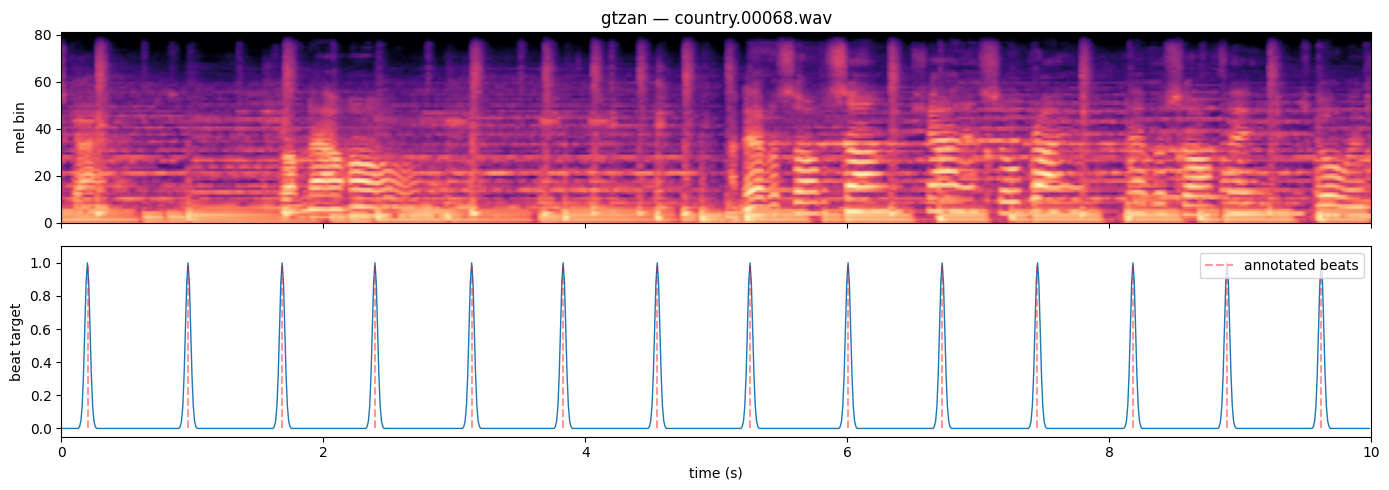

In [21]:
# Deterministic seed
rng = np.random.default_rng(0)

for wav in rng.choice(ballroom_wavs, size=2, replace=False):
    plot_track(wav)

for wav in rng.choice(gtzan_wavs, size=3, replace=False):
    plot_track(wav)

# 2. Dataset, caching

## Cache features for every track

In [22]:
REBUILD_CACHE = False  # set True only the very first time, or after changing feature params

CACHE_DIR = '/content/cache'
DRIVE_CACHE = f'{DRIVE_DATASETS}/feature_cache'
os.makedirs(CACHE_DIR, exist_ok=True)
!mkdir -p "{DRIVE_CACHE}"

if REBUILD_CACHE:
    # Slow path: compute features from audio, then back up to Drive.
    def cache_path(wav_path):
        stem = Path(wav_path).stem
        return f"{CACHE_DIR}/{dataset_of(wav_path)}__{stem}.npz"

    def build_cache(wav_list, force=False):
        from tqdm import tqdm
        for wav in tqdm(wav_list, desc='caching'):
            out = cache_path(wav)
            if os.path.exists(out) and not force:
                continue
            try:
                log_mel, target, _ = process_track(wav)
                np.savez_compressed(out,
                                    log_mel=log_mel.astype(np.float32),
                                    target=target.astype(np.float32))
            except Exception as e:
                print(f"  skipped {Path(wav).name}: {e}")

    build_cache(all_wavs)
    !cp {CACHE_DIR}/*.npz "{DRIVE_CACHE}/"
    print("Cache built and backed up to Drive")
else:
    # Fast path: restore from Drive.
    !cp "{DRIVE_CACHE}"/*.npz {CACHE_DIR}/

# Define cache_path regardless, since the Dataset class uses it:
def cache_path(wav_path):
    stem = Path(wav_path).stem
    return f"{CACHE_DIR}/{dataset_of(wav_path)}__{stem}.npz"

cached = sorted(glob.glob(f'{CACHE_DIR}/*.npz'))
print(f"{len(cached)} cached tracks available")

1696 cached tracks available


## Train/val/test split, by track

In [23]:
# Filter tracks whose cache file exists (drops jazz.00054 and any future failures):
ballroom_wavs = [w for w in ballroom_wavs if os.path.exists(cache_path(w))]
gtzan_wavs    = [w for w in gtzan_wavs    if os.path.exists(cache_path(w))]
print(f"After cache filter — Ballroom: {len(ballroom_wavs)}  GTZAN: {len(gtzan_wavs)}")

rng = np.random.default_rng(42)

def split_tracks(wav_list, val_frac=0.1, test_frac=0.1):
    wavs = list(wav_list)
    rng.shuffle(wavs)
    n_test = int(len(wavs) * test_frac)
    n_val  = int(len(wavs) * val_frac)
    test  = wavs[:n_test]
    val   = wavs[n_test:n_test + n_val]
    train = wavs[n_test + n_val:]
    return train, val, test

# Split each dataset independently so proportions stay balanced across sets.
b_train, b_val, b_test = split_tracks(ballroom_wavs)
g_train, g_val, g_test = split_tracks(gtzan_wavs)

train_wavs = b_train + g_train
val_wavs   = b_val   + g_val
test_wavs  = b_test  + g_test

print(f"train: {len(train_wavs)}  val: {len(val_wavs)}  test: {len(test_wavs)}")

After cache filter — Ballroom: 560  GTZAN: 998
train: 1248  val: 155  test: 155


## Pytorch dataset

In [24]:
import torch
from torch.utils.data import Dataset, DataLoader

EXCERPT_FRAMES = 1500  # 15 seconds at 100 fps

class BeatDataset(Dataset):
    """Returns fixed-length excerpts from cached features.

    Each __getitem__ picks a random 15-second window from the track.
    Tracks shorter than the window are zero-padded.
    """
    def __init__(self, wav_list, excerpt_frames=EXCERPT_FRAMES, training=True):
        self.paths = [cache_path(w) for w in wav_list]
        self.excerpt = excerpt_frames
        self.training = training

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        data = np.load(self.paths[idx])
        log_mel, target = data['log_mel'], data['target']
        T = log_mel.shape[1]

        if T <= self.excerpt:
            # Pad short tracks.
            pad = self.excerpt - T
            log_mel = np.pad(log_mel, ((0, 0), (0, pad)))
            target  = np.pad(target, (0, pad))
        else:
            if self.training:
                start = np.random.randint(0, T - self.excerpt + 1)
            else:
                start = (T - self.excerpt) // 2  # deterministic center crop for val
            log_mel = log_mel[:, start:start + self.excerpt]
            target  = target[start:start + self.excerpt]

        return (torch.from_numpy(log_mel).float(),   # [N_MELS, excerpt]
                torch.from_numpy(target).float())    # [excerpt]

train_ds = BeatDataset(train_wavs, training=True)
val_ds   = BeatDataset(val_wavs,   training=False)
test_ds  = BeatDataset(test_wavs,  training=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)

# Quick check of one batch:
x, y = next(iter(train_loader))
print(f"batch x: {x.shape}, y: {y.shape}")
# Expect: x = [16, 81, 1500], y = [16, 1500]

batch x: torch.Size([16, 81, 1500]), y: torch.Size([16, 1500])


# 3. Model

## Causal TCN model

In [51]:
import torch.nn as nn
import torch.nn.functional as F

class DilatedConv1d(nn.Module):
    """1D conv with either causal (left-only) or symmetric padding."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, causal=True):
        super().__init__()
        self.causal = causal
        pad_total = (kernel_size - 1) * dilation
        if causal:
            self.left_pad, self.right_pad = pad_total, 0
        else:
            self.left_pad = pad_total // 2
            self.right_pad = pad_total - self.left_pad
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation)

    def forward(self, x):
        x = F.pad(x, (self.left_pad, self.right_pad))
        return self.conv(x)


class TCNBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation, dropout=0.1, causal=True):
        super().__init__()
        self.conv1 = DilatedConv1d(channels, channels, kernel_size, dilation, causal)
        self.conv2 = DilatedConv1d(channels, channels, kernel_size, dilation, causal)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        y = F.relu(self.norm1(self.conv1(x)))
        y = self.drop(y)
        y = F.relu(self.norm2(self.conv2(y)))
        y = self.drop(y)
        return x + y


class BeatTCN(nn.Module):
    def __init__(self, n_mels=81, channels=64, kernel_size=5,
                 dilations=(1, 2, 4, 8, 16, 32), dropout=0.1, causal=True):
        super().__init__()
        self.causal = causal
        self.frontend = nn.Sequential(
            nn.Conv2d(1, 16, (3, 3), padding=(1, 1)),
            nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d((3, 1)),
            nn.Conv2d(16, 32, (3, 3), padding=(1, 1)),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d((3, 1)),
            nn.Conv2d(32, 64, (3, 3), padding=(1, 1)),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d((3, 1)),
        )
        self.channel_proj = nn.Conv1d(64 * 3, channels, kernel_size=1)
        self.blocks = nn.ModuleList([
            TCNBlock(channels, kernel_size, d, dropout, causal) for d in dilations
        ])
        self.head = nn.Conv1d(channels, 1, kernel_size=1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.frontend(x)
        B, C, F_dim, T = x.shape
        x = x.reshape(B, C * F_dim, T)
        x = self.channel_proj(x)
        for block in self.blocks:
            x = block(x)
        return self.head(x).squeeze(1)


# Instantiate and sanity-check:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = BeatTCN().to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {n_params:,} parameters, running on {device}")

x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)
with torch.no_grad():
    logits = model(x)
print(f"input: {x.shape}  →  output: {logits.shape}")

# Reload weights
model.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/best.pt"))
model.eval()
print("Reloaded trained causal weights from best.pt")

Model: 284,001 parameters, running on cuda
input: torch.Size([16, 81, 1500])  →  output: torch.Size([16, 1500])
Reloaded trained causal weights from best.pt


# 4. Training

## Peak picking, evaluation

In [26]:
import mir_eval
from scipy.signal import find_peaks

def activation_to_beats(activation, fps=FPS, threshold=0.3, min_interval_s=0.15):
    """Convert per-frame beat activation → list of beat times (seconds).

    Simple peak-picking: find local maxima above threshold, with a minimum
    spacing to prevent double-counting. min_interval_s=0.15 rules out beats
    closer than 150 ms, which corresponds to tempos above 400 BPM.
    """
    min_dist = int(min_interval_s * fps)
    peaks, _ = find_peaks(activation, height=threshold, distance=min_dist)
    return peaks / fps


def evaluate_track(activation, true_beat_times, fps=FPS):
    """Compute mir_eval F-measure for one track's activation."""
    pred_times = activation_to_beats(activation, fps=fps)
    if len(pred_times) == 0 or len(true_beat_times) == 0:
        return 0.0
    # mir_eval's default F-measure uses a 70 ms tolerance window.
    return mir_eval.beat.f_measure(true_beat_times, pred_times)

## Validation function

In [27]:
@torch.no_grad()
def validate(model, val_wavs, device):
    """Run the model on each validation track (full length, not cropped)
    and return (mean_loss, mean_f_measure).
    """
    model.eval()
    losses, f_scores = [], []
    loss_fn = nn.BCEWithLogitsLoss()

    for wav in val_wavs:
        # Load the full track's cached features (no cropping at eval time).
        data = np.load(cache_path(wav))
        log_mel = torch.from_numpy(data['log_mel']).float().unsqueeze(0).to(device)
        target  = torch.from_numpy(data['target']).float().unsqueeze(0).to(device)

        logits = model(log_mel)
        losses.append(loss_fn(logits, target).item())

        # For F-measure: convert activation → predicted beat times,
        # compare against ground-truth annotated times.
        activation = torch.sigmoid(logits).squeeze(0).cpu().numpy()
        true_times, _ = load_beats(annotation_path(wav))
        f_scores.append(evaluate_track(activation, true_times))

    return np.mean(losses), np.mean(f_scores)

## Training loop

In [28]:
from pathlib import Path
import time

CHECKPOINT_DIR = '/content/drive/MyDrive/ECE 490 Neural Networks/Final Project/Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def train(model, train_loader, val_wavs, device,
          epochs=30, lr=1e-3, pos_weight=4.0):
    # pos_weight upweights positive (beat) frames in the loss to counter imbalance.
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight).to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)

    best_f = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_f': []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        model.train()
        train_losses = []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_loss, val_f = validate(model, val_wavs, device)
        scheduler.step(val_f)

        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(val_loss)
        history['val_f'].append(val_f)

        print(f"epoch {epoch:2d}  "
              f"train_loss {np.mean(train_losses):.4f}  "
              f"val_loss {val_loss:.4f}  "
              f"val_F {val_f:.3f}  "
              f"lr {optimizer.param_groups[0]['lr']:.1e}  "
              f"({time.time()-t0:.0f}s)")

        if val_f > best_f:
            best_f = val_f
            torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/best.pt")
            print(f"  ↳ new best F={val_f:.3f}, checkpointed")

    return history

## Train v1

In [29]:
history = train(model, train_loader, val_wavs, device,
                epochs=30, lr=1e-3, pos_weight=4.0)

epoch  1  train_loss 0.5968  val_loss 0.3365  val_F 0.713  lr 1.0e-03  (7s)
  ↳ new best F=0.713, checkpointed
epoch  2  train_loss 0.4941  val_loss 0.3023  val_F 0.756  lr 1.0e-03  (7s)
  ↳ new best F=0.756, checkpointed
epoch  3  train_loss 0.4683  val_loss 0.2811  val_F 0.770  lr 1.0e-03  (7s)
  ↳ new best F=0.770, checkpointed
epoch  4  train_loss 0.4529  val_loss 0.2448  val_F 0.784  lr 1.0e-03  (7s)
  ↳ new best F=0.784, checkpointed
epoch  5  train_loss 0.4402  val_loss 0.2975  val_F 0.774  lr 1.0e-03  (7s)
epoch  6  train_loss 0.4353  val_loss 0.2732  val_F 0.801  lr 1.0e-03  (7s)
  ↳ new best F=0.801, checkpointed
epoch  7  train_loss 0.4236  val_loss 0.2530  val_F 0.800  lr 1.0e-03  (7s)
epoch  8  train_loss 0.4173  val_loss 0.2561  val_F 0.810  lr 1.0e-03  (7s)
  ↳ new best F=0.810, checkpointed
epoch  9  train_loss 0.4144  val_loss 0.2642  val_F 0.810  lr 1.0e-03  (7s)
epoch 10  train_loss 0.4120  val_loss 0.2243  val_F 0.822  lr 1.0e-03  (7s)
  ↳ new best F=0.822, checkpoi

## Reinstate with longer dilation stack

In [ ]:
# Preserve winner
!cp "{CHECKPOINT_DIR}/best.pt" "{CHECKPOINT_DIR}/best_v1.pt"
!ls -lh "{CHECKPOINT_DIR}"

# Fresh model with extended receptive field (dilations 64 and 128 added):
model = BeatTCN(dilations=(1, 2, 4, 8, 16, 32, 64, 128)).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model v2: {n_params:,} parameters, running on {device}")

# Sanity check — forward pass on a real batch should still give matching shapes:
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)
with torch.no_grad():
    logits = model(x)
print(f"input: {x.shape}  →  output: {logits.shape}")

## Train v2

In [33]:
history_v2 = train(model, train_loader, val_wavs, device,
                   epochs=30, lr=1e-3, pos_weight=4.0)

epoch  1  train_loss 0.6210  val_loss 0.3033  val_F 0.735  lr 1.0e-03  (7s)
  ↳ new best F=0.735, checkpointed
epoch  2  train_loss 0.5025  val_loss 0.2509  val_F 0.756  lr 1.0e-03  (7s)
  ↳ new best F=0.756, checkpointed
epoch  3  train_loss 0.4695  val_loss 0.2524  val_F 0.792  lr 1.0e-03  (7s)
  ↳ new best F=0.792, checkpointed
epoch  4  train_loss 0.4505  val_loss 0.2424  val_F 0.805  lr 1.0e-03  (7s)
  ↳ new best F=0.805, checkpointed
epoch  5  train_loss 0.4411  val_loss 0.2617  val_F 0.792  lr 1.0e-03  (7s)
epoch  6  train_loss 0.4368  val_loss 0.4250  val_F 0.728  lr 1.0e-03  (7s)
epoch  7  train_loss 0.4201  val_loss 0.2582  val_F 0.812  lr 1.0e-03  (7s)
  ↳ new best F=0.812, checkpointed
epoch  8  train_loss 0.4147  val_loss 0.2456  val_F 0.799  lr 1.0e-03  (7s)
epoch  9  train_loss 0.4124  val_loss 0.2519  val_F 0.809  lr 1.0e-03  (7s)
epoch 10  train_loss 0.4051  val_loss 0.3297  val_F 0.752  lr 1.0e-03  (7s)
epoch 11  train_loss 0.4034  val_loss 0.2397  val_F 0.822  lr 1.0

## Decide which to keep

In [34]:
# Best F-measure from each run:
v1_best = max(history['val_f'])
v2_best = max(history_v2['val_f'])
print(f"v1 best val_F: {v1_best:.3f}")
print(f"v2 best val_F: {v2_best:.3f}")

if v2_best > v1_best:
    print(f"v2 wins by {v2_best - v1_best:.3f} — keeping v2")
    # best.pt already contains v2 (overwritten during training); nothing to do.
    # But re-instantiate model with the v2 architecture for loading:
    model = BeatTCN(dilations=(1, 2, 4, 8, 16, 32, 64, 128)).to(device)
    model.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/best.pt"))
    FINAL_DILATIONS = (1, 2, 4, 8, 16, 32, 64, 128)
else:
    print(f"v1 wins (or ties) — reverting to v1")
    # Restore v1 checkpoint as the canonical best.pt:
    !cp "{CHECKPOINT_DIR}/best_v1.pt" "{CHECKPOINT_DIR}/best.pt"
    model = BeatTCN(dilations=(1, 2, 4, 8, 16, 32)).to(device)
    model.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/best.pt"))
    FINAL_DILATIONS = (1, 2, 4, 8, 16, 32)

model.eval()
print(f"Final model loaded with dilations={FINAL_DILATIONS}")

v1 best val_F: 0.852
v2 best val_F: 0.851
v1 wins (or ties) — reverting to v1
Final model loaded with dilations=(1, 2, 4, 8, 16, 32)


In [35]:
sweep_thresholds(model, val_wavs, device)

Computing activations for all val tracks...

 threshold   F-measure
      0.15       0.832
      0.20       0.842
      0.25       0.847
      0.30       0.852
      0.35       0.853
      0.40       0.854
      0.45       0.851
      0.50       0.849


### Setting best threshold

In [36]:
BEST_THRESHOLD = 0.40

### Save both histories

In [37]:
import pickle
with open(f"{CHECKPOINT_DIR}/history_v1.pkl", 'wb') as f:
    pickle.dump(history, f)
with open(f"{CHECKPOINT_DIR}/history_v2.pkl", 'wb') as f:
    pickle.dump(history_v2, f)

## Non-causal ablation

In [52]:
# Back up the causal checkpoint before training overwrites best.pt:
!cp "{CHECKPOINT_DIR}/best.pt" "{CHECKPOINT_DIR}/best_causal.pt"

# Fresh non-causal model:
model_nc = BeatTCN(causal=False).to(device)
n_params = sum(p.numel() for p in model_nc.parameters())
print(f"Non-causal model: {n_params:,} parameters")

history_nc = train(model_nc, train_loader, val_wavs, device,
                   epochs=30, lr=1e-3, pos_weight=4.0)

# Save the best non-causal checkpoint with a distinct name:
!cp "{CHECKPOINT_DIR}/best.pt" "{CHECKPOINT_DIR}/best_noncausal.pt"

with open(f"{CHECKPOINT_DIR}/history_noncausal.pkl", 'wb') as f:
    pickle.dump(history_nc, f)

Non-causal model: 284,001 parameters
epoch  1  train_loss 0.5521  val_loss 0.2898  val_F 0.740  lr 1.0e-03  (7s)
  ↳ new best F=0.740, checkpointed
epoch  2  train_loss 0.4656  val_loss 0.3112  val_F 0.766  lr 1.0e-03  (7s)
  ↳ new best F=0.766, checkpointed
epoch  3  train_loss 0.4383  val_loss 0.2858  val_F 0.757  lr 1.0e-03  (7s)
epoch  4  train_loss 0.4289  val_loss 0.2491  val_F 0.789  lr 1.0e-03  (7s)
  ↳ new best F=0.789, checkpointed
epoch  5  train_loss 0.4097  val_loss 0.2659  val_F 0.798  lr 1.0e-03  (7s)
  ↳ new best F=0.798, checkpointed
epoch  6  train_loss 0.4064  val_loss 0.2357  val_F 0.809  lr 1.0e-03  (7s)
  ↳ new best F=0.809, checkpointed
epoch  7  train_loss 0.3937  val_loss 0.2795  val_F 0.783  lr 1.0e-03  (7s)
epoch  8  train_loss 0.3942  val_loss 0.2860  val_F 0.762  lr 1.0e-03  (7s)
epoch  9  train_loss 0.3899  val_loss 0.2525  val_F 0.815  lr 1.0e-03  (7s)
  ↳ new best F=0.815, checkpointed
epoch 10  train_loss 0.3795  val_loss 0.2615  val_F 0.811  lr 1.0e-03

# 5. Evaluation

## Training curves (v1 vs v2)

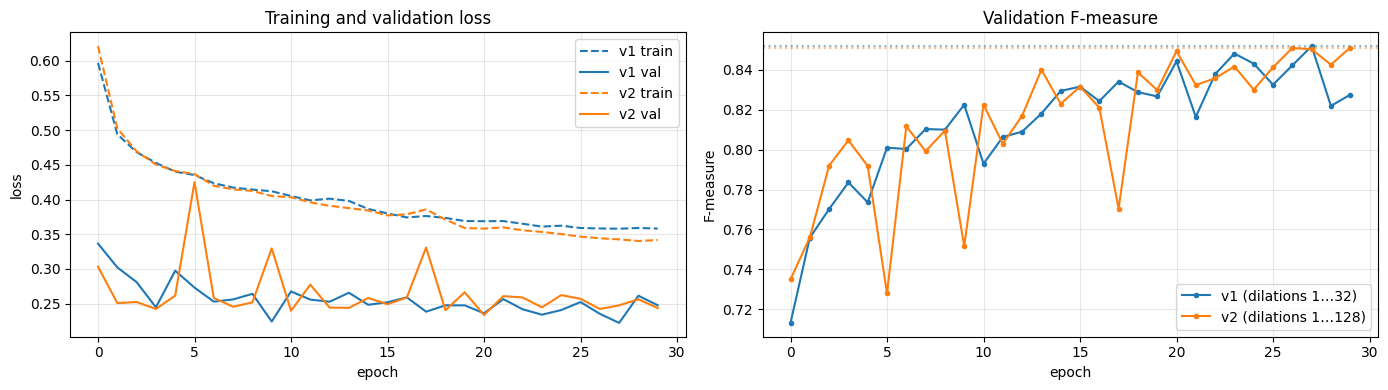

Saved to Drive as training_curves.png


In [38]:
import pickle

with open(f"{CHECKPOINT_DIR}/history_v1.pkl", 'rb') as f:
    h1 = pickle.load(f)
with open(f"{CHECKPOINT_DIR}/history_v2.pkl", 'rb') as f:
    h2 = pickle.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: loss curves
ax = axes[0]
ax.plot(h1['train_loss'], label='v1 train', color='tab:blue', linestyle='--')
ax.plot(h1['val_loss'],   label='v1 val',   color='tab:blue')
ax.plot(h2['train_loss'], label='v2 train', color='tab:orange', linestyle='--')
ax.plot(h2['val_loss'],   label='v2 val',   color='tab:orange')
ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax.set_title('Training and validation loss')
ax.legend(); ax.grid(alpha=0.3)

# Right: val F-measure
ax = axes[1]
ax.plot(h1['val_f'], label='v1 (dilations 1…32)',  color='tab:blue',   marker='.')
ax.plot(h2['val_f'], label='v2 (dilations 1…128)', color='tab:orange', marker='.')
ax.axhline(max(h1['val_f']), color='tab:blue',   linestyle=':', alpha=0.5)
ax.axhline(max(h2['val_f']), color='tab:orange', linestyle=':', alpha=0.5)
ax.set_xlabel('epoch'); ax.set_ylabel('F-measure')
ax.set_title('Validation F-measure')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive as training_curves.png")

## Full mir_eval metrics helper

In [39]:
@torch.no_grad()
def evaluate_tracks(model, wav_list, device, threshold=BEST_THRESHOLD):
    """Run model on each track, return dict of metric_name → list of per-track scores."""
    model.eval()
    metrics = {'F': [], 'Cemgil': [], 'CMLt': [], 'AMLt': []}

    for wav in wav_list:
        data = np.load(cache_path(wav))
        log_mel = torch.from_numpy(data['log_mel']).float().unsqueeze(0).to(device)
        logits = model(log_mel)
        activation = torch.sigmoid(logits).squeeze(0).cpu().numpy()

        pred_times = activation_to_beats(activation, threshold=threshold)
        true_times, _ = load_beats(annotation_path(wav))

        if len(pred_times) == 0 or len(true_times) == 0:
            for k in metrics: metrics[k].append(0.0)
            continue

        scores = mir_eval.beat.evaluate(true_times, pred_times)
        metrics['F'].append(scores['F-measure'])
        metrics['Cemgil'].append(scores['Cemgil'])
        metrics['CMLt'].append(scores['Correct Metric Level Total'])
        metrics['AMLt'].append(scores['Any Metric Level Total'])

    return metrics

def summarize(metrics, label):
    print(f"\n{label}:")
    for name, vals in metrics.items():
        print(f"  {name:8s}  {np.mean(vals):.3f} ± {np.std(vals):.3f}  (n={len(vals)})")

## Final test-set metrics, overall and per dataset

In [40]:
print("Evaluating on test set...")
test_metrics = evaluate_tracks(model, test_wavs, device)
summarize(test_metrics, "Test set (all)")

# Per-dataset breakdown:
ballroom_test = [w for w in test_wavs if dataset_of(w) == 'ballroom']
gtzan_test    = [w for w in test_wavs if dataset_of(w) == 'gtzan']

br_metrics = evaluate_tracks(model, ballroom_test, device)
gt_metrics = evaluate_tracks(model, gtzan_test,    device)

summarize(br_metrics, f"Ballroom test ({len(ballroom_test)} tracks)")
summarize(gt_metrics, f"GTZAN test    ({len(gtzan_test)} tracks)")

Evaluating on test set...


/usr/local/lib/python3.12/dist-packages/mir_eval/beat.py:368: UserWarning: Only one estimated beat was provided, so beat intervals cannot be computed.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mir_eval/beat.py:463: UserWarning: Only one estimated beat was provided, so beat intervals cannot be computed.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mir_eval/beat.py:629: UserWarning: Only one estimated beat was provided, so beat intervals cannot be computed.
  warnings.warn(



Test set (all):
  F         0.839 ± 0.243  (n=155)
  Cemgil    0.786 ± 0.243  (n=155)
  CMLt      0.704 ± 0.344  (n=155)
  AMLt      0.747 ± 0.295  (n=155)

Ballroom test (56 tracks):
  F         0.908 ± 0.154  (n=56)
  Cemgil    0.862 ± 0.167  (n=56)
  CMLt      0.801 ± 0.276  (n=56)
  AMLt      0.835 ± 0.211  (n=56)

GTZAN test    (99 tracks):
  F         0.800 ± 0.273  (n=99)
  Cemgil    0.742 ± 0.268  (n=99)
  CMLt      0.649 ± 0.366  (n=99)
  AMLt      0.697 ± 0.323  (n=99)


## Qualitative examples

Worst 3:
  F=0.000  gtzan      jazz.00009.wav
  F=0.000  gtzan      jazz.00014.wav
  F=0.000  gtzan      jazz.00003.wav
Best 3:
  F=1.000  gtzan      disco.00049.wav
  F=1.000  gtzan      pop.00091.wav
  F=1.000  gtzan      jazz.00044.wav

--- Best cases ---


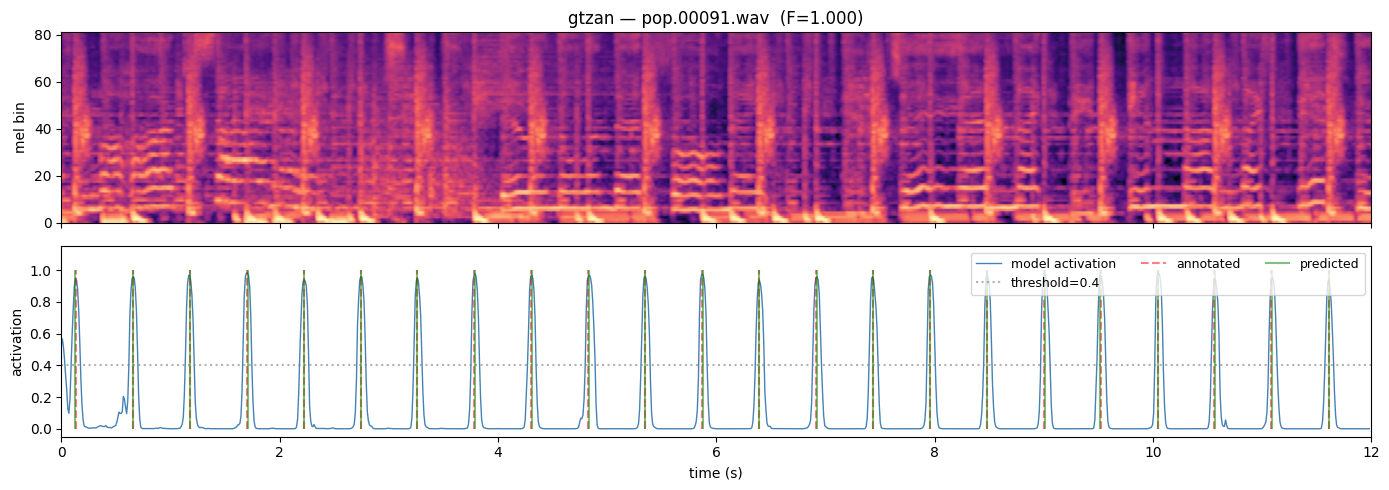

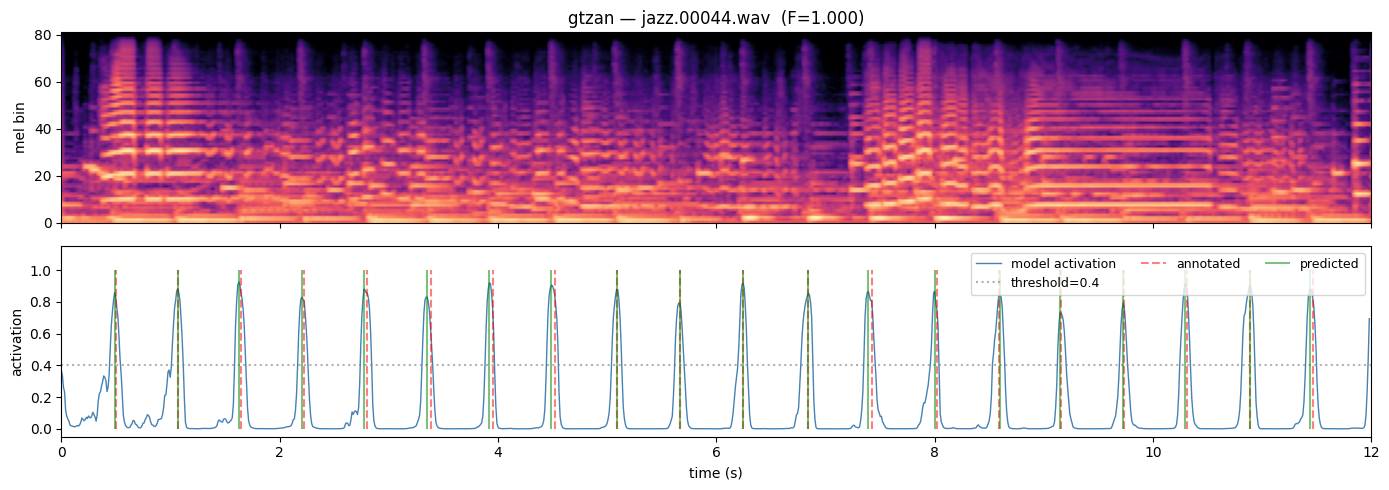


--- Worst cases ---


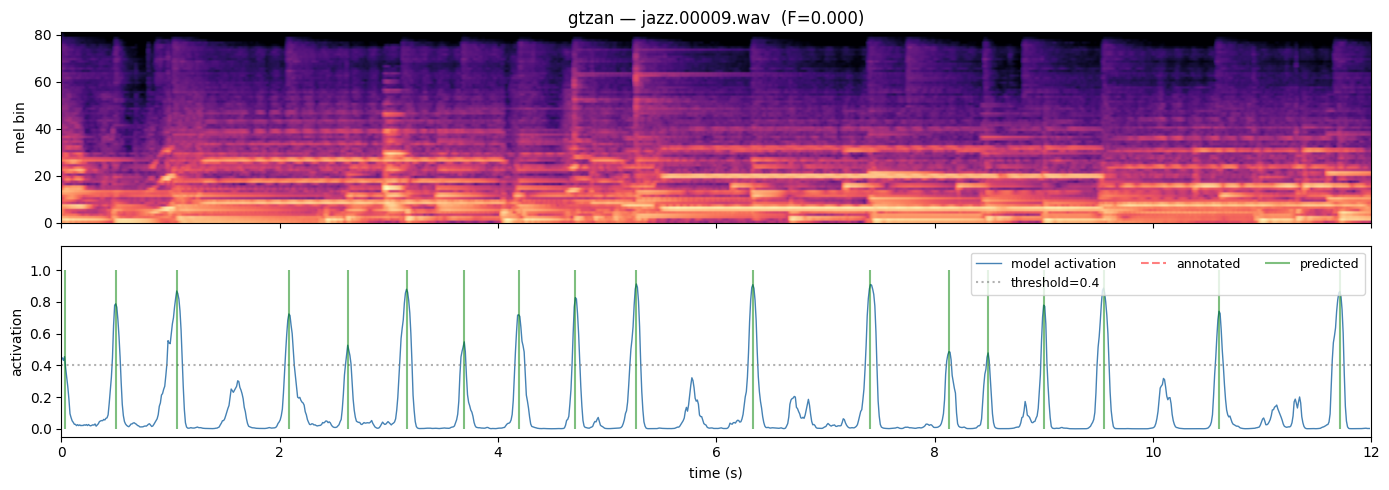

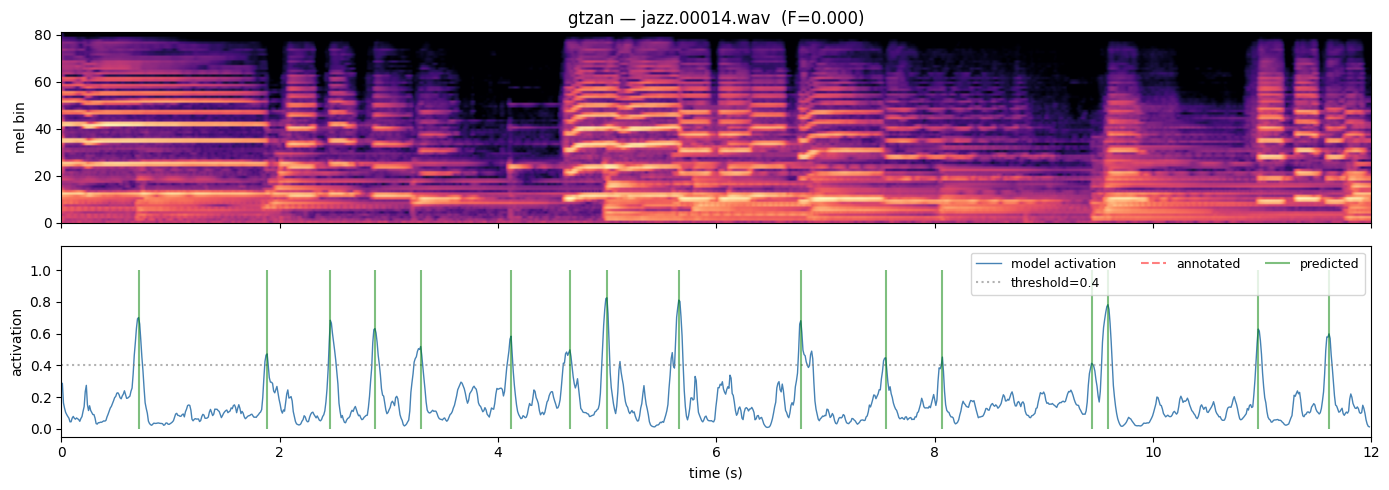

In [41]:
# Rank test tracks by F-measure to find interesting examples:
test_results = []
for wav in test_wavs:
    data = np.load(cache_path(wav))
    log_mel = torch.from_numpy(data['log_mel']).float().unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(log_mel)
    activation = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    pred = activation_to_beats(activation, threshold=BEST_THRESHOLD)
    true, _ = load_beats(annotation_path(wav))
    f = mir_eval.beat.f_measure(true, pred) if len(pred) and len(true) else 0.0
    test_results.append((f, wav, activation, pred, true))

test_results.sort(key=lambda r: r[0])

print("Worst 3:")
for f, wav, *_ in test_results[:3]:
    print(f"  F={f:.3f}  {dataset_of(wav):9s}  {Path(wav).name}")
print("Best 3:")
for f, wav, *_ in test_results[-3:]:
    print(f"  F={f:.3f}  {dataset_of(wav):9s}  {Path(wav).name}")


def plot_prediction(wav, activation, pred_times, true_times, f_score, window_s=12):
    """Plot spectrogram, activation with threshold line, predicted vs. true beats."""
    data = np.load(cache_path(wav))
    log_mel = data['log_mel']
    max_frame = int(window_s * FPS)
    t_axis = np.arange(max_frame) / FPS

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    axes[0].imshow(log_mel[:, :max_frame], aspect='auto', origin='lower',
                   extent=[0, window_s, 0, N_MELS], cmap='magma')
    axes[0].set_title(f'{dataset_of(wav)} — {Path(wav).name}  (F={f_score:.3f})')
    axes[0].set_ylabel('mel bin')

    axes[1].plot(t_axis, activation[:max_frame], color='steelblue',
                 linewidth=1, label='model activation')
    axes[1].axhline(BEST_THRESHOLD, color='gray', linestyle=':',
                    alpha=0.6, label=f'threshold={BEST_THRESHOLD}')
    axes[1].vlines(true_times[true_times < window_s], 0, 1, colors='red',
                   alpha=0.5, linestyles='dashed', label='annotated')
    axes[1].vlines(pred_times[pred_times < window_s], 0, 1, colors='green',
                   alpha=0.5, linestyles='solid', label='predicted')
    axes[1].set_xlabel('time (s)')
    axes[1].set_ylabel('activation')
    axes[1].set_ylim(-0.05, 1.15)
    axes[1].legend(loc='upper right', ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()

# Two clean successes and two failures:
print("\n--- Best cases ---")
for f, wav, act, pred, true in test_results[-2:]:
    plot_prediction(wav, act, pred, true, f)

print("\n--- Worst cases ---")
for f, wav, act, pred, true in test_results[:2]:
    plot_prediction(wav, act, pred, true, f)

### Inspecting worst failure

In [43]:
wav = '/content/gtzan/Data/genres_original/jazz/jazz.00009.wav'
true, pos = load_beats(annotation_path(wav))
print(f"{len(true)} annotated beats, first: {true[:6]}, last: {true[-3:]}")

0 annotated beats, first: [], last: []


### Audit for empty/sparse annotations

In [44]:
# Check all tracks for annotation completeness:
empty_tracks = []
sparse_tracks = []  # fewer than 5 annotated beats — probably also broken

for wav in all_wavs:
    true, _ = load_beats(annotation_path(wav))
    if len(true) == 0:
        empty_tracks.append(wav)
    elif len(true) < 5:
        sparse_tracks.append((wav, len(true)))

print(f"Empty annotations: {len(empty_tracks)}")
for w in empty_tracks:
    print(f"  {dataset_of(w):9s}  {Path(w).name}")

print(f"\nSparse annotations (<5 beats): {len(sparse_tracks)}")
for w, n in sparse_tracks:
    print(f"  {dataset_of(w):9s}  {Path(w).name}  ({n} beats)")

Empty annotations: 6
  gtzan      jazz.00003.wav
  gtzan      jazz.00009.wav
  gtzan      jazz.00010.wav
  gtzan      jazz.00014.wav
  gtzan      jazz.00018.wav
  gtzan      jazz.00020.wav

Sparse annotations (<5 beats): 0


### Filtering out empty/sparse annotations from evaluation

In [47]:
def has_annotations(wav, min_beats=5):
    true, _ = load_beats(annotation_path(wav))
    return len(true) >= min_beats

# Filter the evaluation sets:
clean_test_wavs     = [w for w in test_wavs     if has_annotations(w)]
clean_ballroom_test = [w for w in ballroom_test if has_annotations(w)]
clean_gtzan_test    = [w for w in gtzan_test    if has_annotations(w)]

print(f"Test: {len(test_wavs)} → {len(clean_test_wavs)} after filter")
print(f"  Ballroom: {len(ballroom_test)} → {len(clean_ballroom_test)}")
print(f"  GTZAN:    {len(gtzan_test)}    → {len(clean_gtzan_test)}")

# Re-evaluate with the cleaned sets:
print("\nRe-evaluating with annotation-clean test set...")
test_metrics = evaluate_tracks(model, clean_test_wavs, device)
br_metrics   = evaluate_tracks(model, clean_ballroom_test, device)
gt_metrics   = evaluate_tracks(model, clean_gtzan_test, device)

summarize(test_metrics, "Test set (all, clean)")
summarize(br_metrics,   f"Ballroom test ({len(clean_ballroom_test)} tracks)")
summarize(gt_metrics,   f"GTZAN test    ({len(clean_gtzan_test)} tracks)")

Test: 155 → 152 after filter
  Ballroom: 56 → 56
  GTZAN:    99    → 96

Re-evaluating with annotation-clean test set...

Test set (all, clean):
  F         0.855 ± 0.214  (n=152)
  Cemgil    0.801 ± 0.219  (n=152)
  CMLt      0.718 ± 0.333  (n=152)
  AMLt      0.761 ± 0.278  (n=152)

Ballroom test (56 tracks):
  F         0.908 ± 0.154  (n=56)
  Cemgil    0.862 ± 0.167  (n=56)
  CMLt      0.801 ± 0.276  (n=56)
  AMLt      0.835 ± 0.211  (n=56)

GTZAN test    (96 tracks):
  F         0.825 ± 0.237  (n=96)
  Cemgil    0.765 ± 0.237  (n=96)
  CMLt      0.669 ± 0.353  (n=96)
  AMLt      0.718 ± 0.303  (n=96)


## Summary

In [48]:
print(f"\n{'':20s}  {'F':>7s}  {'Cemgil':>7s}  {'CMLt':>7s}  {'AMLt':>7s}")
print("-" * 56)
for label, m in [('Test (all)', test_metrics),
                 ('  Ballroom', br_metrics),
                 ('  GTZAN',    gt_metrics)]:
    row = f"{label:20s}  " + "  ".join(
        f"{np.mean(m[k]):7.3f}" for k in ['F','Cemgil','CMLt','AMLt'])
    print(row)


                            F   Cemgil     CMLt     AMLt
--------------------------------------------------------
Test (all)              0.855    0.801    0.718    0.761
  Ballroom              0.908    0.862    0.801    0.835
  GTZAN                 0.825    0.765    0.669    0.718


## Per-genre breakdown within GTZAN

Evaluating on 992 GTZAN tracks...

     genre    F (mean)     F (std)     n
----------------------------------------
    reggae       0.958       0.073    99
     disco       0.956       0.114   100
    hiphop       0.923       0.099   100
   country       0.915       0.119   100
       pop       0.900       0.148   100
      rock       0.886       0.119   100
     metal       0.873       0.145   100
      jazz       0.842       0.185    93
     blues       0.837       0.175   100
 classical       0.588       0.267   100


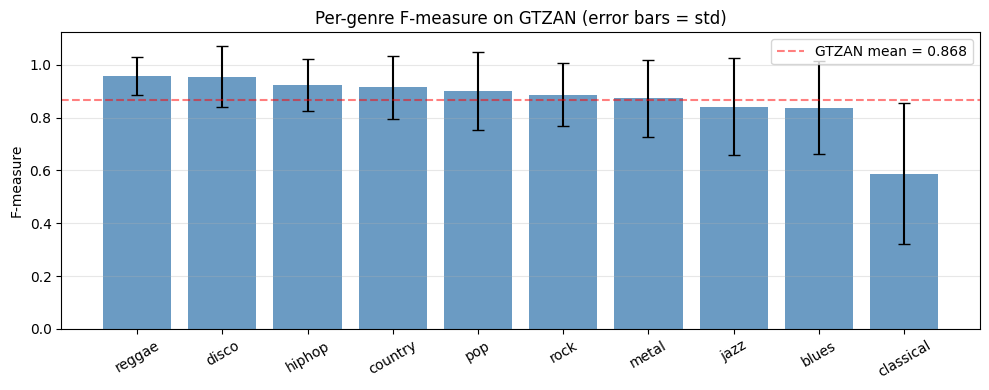

In [49]:
import re

def gtzan_genre(wav_path):
    """Extract genre from filename like 'jazz.00009.wav' → 'jazz'."""
    m = re.match(r'([a-z]+)\.', Path(wav_path).name)
    return m.group(1) if m else 'unknown'

# Use the full GTZAN eval set (not just test) for more tracks per genre.
# Filter out empty annotations:
gtzan_eval = [w for w in gtzan_wavs if has_annotations(w)]
print(f"Evaluating on {len(gtzan_eval)} GTZAN tracks...")

# Run model on all of them:
gtzan_f_by_track = []
for wav in gtzan_eval:
    data = np.load(cache_path(wav))
    log_mel = torch.from_numpy(data['log_mel']).float().unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(log_mel)
    activation = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    pred = activation_to_beats(activation, threshold=BEST_THRESHOLD)
    true, _ = load_beats(annotation_path(wav))
    f = mir_eval.beat.f_measure(true, pred) if len(pred) and len(true) else 0.0
    gtzan_f_by_track.append((gtzan_genre(wav), f))

# Aggregate by genre:
from collections import defaultdict
by_genre = defaultdict(list)
for genre, f in gtzan_f_by_track:
    by_genre[genre].append(f)

genres = sorted(by_genre.keys())
means = [np.mean(by_genre[g]) for g in genres]
stds  = [np.std(by_genre[g]) for g in genres]
ns    = [len(by_genre[g]) for g in genres]

# Print table:
print(f"\n{'genre':>10}  {'F (mean)':>10}  {'F (std)':>10}  {'n':>4}")
print('-' * 40)
for g, m, s, n in sorted(zip(genres, means, stds, ns), key=lambda r: -r[1]):
    print(f"{g:>10}  {m:>10.3f}  {s:>10.3f}  {n:>4}")

# Plot:
order = np.argsort(means)[::-1]  # descending
sorted_genres = [genres[i] for i in order]
sorted_means = [means[i] for i in order]
sorted_stds = [stds[i] for i in order]

plt.figure(figsize=(10, 4))
plt.bar(sorted_genres, sorted_means, yerr=sorted_stds, capsize=4,
        color='steelblue', alpha=0.8)
plt.axhline(np.mean(means), color='red', linestyle='--', alpha=0.5,
            label=f'GTZAN mean = {np.mean(means):.3f}')
plt.ylabel('F-measure')
plt.title('Per-genre F-measure on GTZAN (error bars = std)')
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/per_genre_f.png", dpi=150, bbox_inches='tight')
plt.show()

## Activation latency measurement

Matched beats: 8748
Mean offset:   +0.5 ms
Median offset: +0.5 ms
Std:           16.5 ms


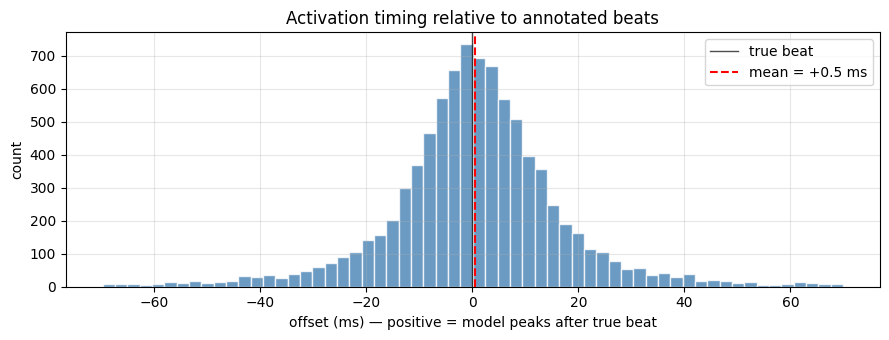

In [50]:
# For each correctly-predicted beat, measure the offset between the activation
# peak and the true annotated beat time. Shows systematic latency.
offsets = []  # seconds (predicted - true); positive means model peaks AFTER beat

# Use val set for this analysis so test set metrics stay for final report.
for wav in val_wavs:
    if not has_annotations(wav):
        continue
    data = np.load(cache_path(wav))
    log_mel = torch.from_numpy(data['log_mel']).float().unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(log_mel)
    activation = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    pred = activation_to_beats(activation, threshold=BEST_THRESHOLD)
    true, _ = load_beats(annotation_path(wav))

    # For each true beat, find the nearest predicted beat within 70 ms:
    for t in true:
        if len(pred) == 0:
            continue
        dists = pred - t
        idx = np.argmin(np.abs(dists))
        if abs(dists[idx]) <= 0.070:  # within F-measure tolerance window
            offsets.append(dists[idx])

offsets = np.array(offsets)
print(f"Matched beats: {len(offsets)}")
print(f"Mean offset:   {1000*np.mean(offsets):+.1f} ms")
print(f"Median offset: {1000*np.median(offsets):+.1f} ms")
print(f"Std:           {1000*np.std(offsets):.1f} ms")

# Histogram:
plt.figure(figsize=(9, 3.5))
plt.hist(1000*offsets, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
plt.axvline(0, color='black', linewidth=1, alpha=0.7, label='true beat')
plt.axvline(1000*np.mean(offsets), color='red', linestyle='--',
            label=f'mean = {1000*np.mean(offsets):+.1f} ms')
plt.xlabel('offset (ms) — positive = model peaks after true beat')
plt.ylabel('count')
plt.title('Activation timing relative to annotated beats')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/latency_histogram.png", dpi=150, bbox_inches='tight')
plt.show()

## Causal vs non-causal comparison

In [53]:
# Load both models from their checkpoints:
model_causal = BeatTCN(causal=True).to(device)
model_causal.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/best_causal.pt"))
model_causal.eval()

model_noncausal = BeatTCN(causal=False).to(device)
model_noncausal.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/best_noncausal.pt"))
model_noncausal.eval()

# Re-sweep threshold for the non-causal model on val:
print("Threshold sweep for non-causal model:")
sweep_thresholds(model_noncausal, val_wavs, device)

Threshold sweep for non-causal model:
Computing activations for all val tracks...

 threshold   F-measure
      0.15       0.849
      0.20       0.858
      0.25       0.863
      0.30       0.866
      0.35       0.868
      0.40       0.870
      0.45       0.872
      0.50       0.871


In [54]:
NC_THRESHOLD = 0.45  # picked from sweep in above cell

m_c  = evaluate_tracks(model_causal,    clean_test_wavs, device, threshold=BEST_THRESHOLD)
m_nc = evaluate_tracks(model_noncausal, clean_test_wavs, device, threshold=NC_THRESHOLD)

print(f"\n{'':20s}  {'F':>7s}  {'Cemgil':>7s}  {'CMLt':>7s}  {'AMLt':>7s}")
print('-' * 56)
for label, m in [('Causal',     m_c),
                 ('Non-causal', m_nc)]:
    row = f"{label:20s}  " + "  ".join(
        f"{np.mean(m[k]):7.3f}" for k in ['F','Cemgil','CMLt','AMLt'])
    print(row)

# Non-causal latency for comparison:
print("\nNon-causal activation timing:")
nc_offsets = []
for wav in val_wavs:
    if not has_annotations(wav): continue
    data = np.load(cache_path(wav))
    log_mel = torch.from_numpy(data['log_mel']).float().unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model_noncausal(log_mel)
    activation = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    pred = activation_to_beats(activation, threshold=NC_THRESHOLD)
    true, _ = load_beats(annotation_path(wav))
    for t in true:
        if len(pred) == 0: continue
        dists = pred - t
        idx = np.argmin(np.abs(dists))
        if abs(dists[idx]) <= 0.070:
            nc_offsets.append(dists[idx])
nc_offsets = np.array(nc_offsets)
print(f"  Mean offset: {1000*np.mean(nc_offsets):+.1f} ms  (causal was +0.5 ms)")
print(f"  Std:         {1000*np.std(nc_offsets):.1f} ms")

# Reset `model` back to the causal one so nothing downstream breaks:
model = model_causal


                            F   Cemgil     CMLt     AMLt
--------------------------------------------------------
Causal                  0.855    0.801    0.718    0.761
Non-causal              0.873    0.822    0.756    0.812

Non-causal activation timing:
  Mean offset: +2.4 ms  (causal was +0.5 ms)
  Std:         15.9 ms

`model` restored to causal version for any further cells.
